# Day 3: Time Series Analysis & Feature Engineering
**Hakeem • SparkCity**

Deliverables: a time-series dashboard, correlation findings, a reusable feature pipeline, and trend reports. Run all cells using the project `.venv` kernel (`uv sync --dev`).

Read a completed Day 2 snapshot; write a new local `data/processed/day3/<run>` directory. No S2 access. Dashboard charts summarize the six time-varying datasets; city zones remain reference data.

## 1. Setup and select the Day 2 snapshot
Set `DAY2_RUN` to a specific directory name for repeatability, or leave it `None` to select the latest complete run. The chosen run is recorded in the Day 3 manifest. Source timestamps retain wall-clock semantics: UTC is the Spark processing setting, not a claim about source timezone. Measurements retain source units unless Day 2 documented conversions.

In [1]:
import os
import sys
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from pyspark.sql import SparkSession, functions as F, Window
from sparkcityx.data_quality import validate_dataframe, get_validation_config

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/sparkcityx").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start this notebook inside SparkCity_Capstone.")
java_home = Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
if not os.getenv("JAVA_HOME") and java_home.exists():
    os.environ["JAVA_HOME"] = str(java_home)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
spark = (SparkSession.builder.master("local[2]").appName("Hakeem-Day3")
         .config("spark.ui.enabled", "false")
         .config("spark.sql.shuffle.partitions", "4")
         .config("spark.sql.session.timeZone", "UTC").getOrCreate())
spark.conf.set("spark.sql.session.timeZone", "UTC")
spark.sparkContext.setLogLevel("ERROR")
DAY2_RUN = None  # Set to a specific completed Day 2 run to pin the input.
base = ROOT / "data/processed/day2"
complete = sorted(p.parent for p in base.glob("*/manifest.json")
                  if json.loads(p.read_text()).get("status") == "complete")
DAY2 = base / DAY2_RUN if DAY2_RUN else (complete[-1] if complete else None)
if DAY2 is None or not (DAY2 / "manifest.json").exists():
    raise RuntimeError("Run Hakeem_day2.ipynb successfully first.")
source_manifest = json.loads((DAY2 / "manifest.json").read_text())
if source_manifest.get("status") != "complete":
    raise ValueError("Selected Day 2 run is incomplete.")
if not source_manifest.get("day1_run"):
    raise ValueError("Run the updated Day 2 notebook first; this snapshot lacks the corrected Day 1 handoff.")
source_manifest_hash = hashlib.sha256((DAY2 / "manifest.json").read_bytes()).hexdigest()

def dataset_hash(path):
    digest = hashlib.sha256()
    for item in sorted(path.rglob("*")):
        if item.is_file():
            digest.update(str(item.relative_to(path)).encode())
            with item.open("rb") as handle:
                for block in iter(lambda: handle.read(1024 * 1024), b""):
                    digest.update(block)
    return digest.hexdigest()

expected_names = {"traffic", "air_quality", "weather", "energy", "occupancy", "fiscal", "city_zones"}
if {r["dataset"] for r in source_manifest["datasets"]} != expected_names:
    raise ValueError("Day 2 must contain the seven expected datasets.")
input_hashes = {}
for kind in sorted(expected_names):
    path = DAY2 / kind
    if not path.is_dir():
        raise FileNotFoundError(path)
    input_hashes[kind] = dataset_hash(path)
print("Original Day 1 snapshot:", source_manifest["day1_run"])
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/day3" / RUN_ID
OUTPUT.mkdir(parents=True, exist_ok=False)
# Representative measurement for each dashboard series; source units retained.
SERIES = {"traffic": "vehicle_count", "air_quality": "pm25", "weather": "temperature",
          "energy": "power_consumption", "occupancy": "occupied_rooms", "fiscal": "revenue"}
FEATURE_COLUMNS = {
    "traffic": ["vehicle_count", "avg_speed"], "air_quality": ["pm25", "pm10"],
    "weather": ["temperature", "precipitation"], "energy": ["power_consumption", "current"],
    "occupancy": ["occupied_rooms", "guests"], "fiscal": ["revenue", "expense"],
}
sns.set_theme(style="whitegrid")
print("Day 2 source:", DAY2)
print("Day 3 output:", OUTPUT)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/14 10:22:08 WARN Utils: Your hostname, Zipcoders-MacBook-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.88.25 instead (on interface en0)
26/09/14 10:22:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/14 10:22:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Original Day 1 snapshot: 20260914T135810735977Z
Day 2 source: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day2/20260914T135902169587Z
Day 3 output: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day3/20260914T142210469836Z


## 2. Coverage and temporal patterns
Inspect dataset span, sensor coverage and observed reporting intervals before choosing lags. Daily means below weight each observation equally; they are not population-weighted city estimates. Partial days remain visible with sample counts.

Hourly and weekday profiles summarize the available sample, not independently established seasonality. Long gaps and changing sensor composition can affect apparent trends.

In [2]:
frames, coverage, daily, hourly, weekday = {}, [], {}, {}, {}
expected = {r["dataset"]: r["accepted_rows"] for r in source_manifest["datasets"]}
for kind, value in SERIES.items():
    df = spark.read.parquet(str(DAY2 / kind)).cache()
    report = validate_dataframe(df, kind)
    assert report["valid"] and report["record_count"] == expected[kind], kind
    key = get_validation_config(kind)["duplicate_columns"][0]
    stats = df.agg(F.date_format(F.min("timestamp"), "yyyy-MM-dd HH:mm:ss").alias("start"),
                   F.date_format(F.max("timestamp"), "yyyy-MM-dd HH:mm:ss").alias("end"),
                   F.countDistinct(key).alias("sensors")).first()
    w = Window.partitionBy(key).orderBy("timestamp")
    intervals = df.withColumn("_gap_seconds", F.col("timestamp").cast("long") -
                              F.lag("timestamp").over(w).cast("long"))
    gaps = intervals.approxQuantile("_gap_seconds", [0.5, 0.95], 0.001)
    coverage.append({"dataset": kind, "rows": report["record_count"], **stats.asDict(),
                     "median_gap_hours": gaps[0] / 3600 if gaps else None,
                     "p95_gap_hours": gaps[1] / 3600 if gaps else None})
    d = (df.groupBy(F.to_date("timestamp").alias("date"))
         .agg(F.avg(value).alias("mean"), F.count("*").alias("n"),
              F.countDistinct(key).alias("sensors")).orderBy("date").toPandas())
    d["date"] = pd.to_datetime(d["date"])
    daily[kind] = d.set_index("date")
    hourly[kind] = (df.groupBy(F.hour("timestamp").alias("hour"))
                    .agg(F.avg(value).alias("mean"), F.count("*").alias("n"))
                    .orderBy("hour").toPandas())
    weekday[kind] = (df.groupBy(F.dayofweek("timestamp").alias("weekday_sun1"))
                     .agg(F.avg(value).alias("mean"), F.count("*").alias("n"))
                     .orderBy("weekday_sun1").toPandas())
    frames[kind] = df
coverage_df = pd.DataFrame(coverage)
display(coverage_df)
coverage_df.to_csv(OUTPUT / "coverage.csv", index=False)
assert set(["zone_id", "zone_name", "zone_type", "zone_match_count"]) <= set(frames["traffic"].columns)
print("Coverage timestamps use Spark UTC processing display; source timezone remains unconfirmed.")


,dataset,rows,start,end,sensors,median_gap_hours,p95_gap_hours
0,traffic,36000,2025-01-01 00:00:00,2025-05-05 23:55:00,3000,250.0,250.0
1,air_quality,36000,2025-01-01 00:00:00,2026-01-10 23:45:00,1800,450.0,450.0
2,weather,36000,2025-01-01 00:00:00,2027-01-20 23:30:00,1200,600.0,600.0
3,energy,36000,2025-01-01 00:00:00,2025-09-07 23:50:00,2400,400.0,400.0
4,occupancy,36000,2025-01-01 00:00:00,2026-01-10 23:45:00,1200,300.0,300.0
5,fiscal,36000,2025-01-01 00:00:00,2026-01-10 23:45:00,1200,300.0,300.0


Coverage timestamps use Spark UTC processing display; source timezone remains unconfirmed.


## 3. Feature engineering
Lags mean previous **observations**, not previous hours. Rolling statistics use the same sensor's observations in the prior 7 or 30 elapsed days, excluding the current timestamp. A window with no history keeps null statistics and count zero.

Calendar features are known at prediction time. Lag/rolling features use only past observations. Rates of change and interactions use the current reading: these are descriptive features, or predictors of a future target only. Never use current readings to predict that same reading. Split model data chronologically; fit any future scaler or imputer on training data only.

No cross-dataset sensor-ID join is assumed: TRF/AIR/ENG identifiers do not establish colocated sensors. Traffic retains the generated-zone mapping from Day 1; export daily zone aggregates with counts of ambiguous assignments. The spatial study below audits coordinate stability before considering nearby pairs; unstable sensor locations are not treated as fixed sites.
Additional lags of 6, 12 and 24 observations follow the instructor's examples, with availability reported explicitly. They are not hours. Percentage changes require a nonzero previous value. Position relative to a prior range may be below 0 or above 1; a missing/constant range stays null. Algebraic interactions (count × speed, temperature × humidity, voltage × current) are not validated flow, heat-index or efficiency measures.


In [3]:
def engineer_time_features(df, sensor_col, value_columns):
    order = Window.partitionBy(sensor_col).orderBy("timestamp")
    result = (df.withColumn("_epoch", F.col("timestamp").cast("long"))
              .withColumn("hour", F.hour("timestamp"))
              .withColumn("weekday_sun1", F.dayofweek("timestamp"))
              .withColumn("year", F.year("timestamp"))
              .withColumn("month", F.month("timestamp"))
              .withColumn("day_of_month", F.dayofmonth("timestamp"))
              .withColumn("week_of_year", F.weekofyear("timestamp"))
              .withColumn("is_weekend", F.dayofweek("timestamp").isin(1, 7))
              .withColumn("hour_sin", F.sin(2 * np.pi * F.col("hour") / 24))
              .withColumn("hour_cos", F.cos(2 * np.pi * F.col("hour") / 24))
              .withColumn("weekday_sin", F.sin(2 * np.pi * (F.col("weekday_sun1") - 1) / 7))
              .withColumn("weekday_cos", F.cos(2 * np.pi * (F.col("weekday_sun1") - 1) / 7))
              .withColumn("previous_observation_at", F.lag("timestamp").over(order))
              .withColumn("elapsed_hours", (F.col("_epoch") -
                          F.col("previous_observation_at").cast("long")) / 3600))
    for c in value_columns:
        result = result.withColumn(c + "_lag1_observation", F.lag(c, 1).over(order))
        result = result.withColumn(c + "_lag2_observations", F.lag(c, 2).over(order))
        result = result.withColumn(c + "_change_per_hour", F.when(F.col("elapsed_hours") > 0,
            (F.col(c) - F.col(c + "_lag1_observation")) / F.col("elapsed_hours")))
        for lag in (6, 12, 24):
            result = result.withColumn(f"{c}_lag{lag}_observations", F.lag(c, lag).over(order))
        prior = F.col(c + "_lag1_observation")
        result = (result.withColumn(c + "_difference1_observation", F.col(c) - prior)
                  .withColumn(c + "_pct_change1_observation",
                              F.when(prior != 0, 100 * (F.col(c) - prior) / prior)))
        for days in (7, 30):
            window = Window.partitionBy(sensor_col).orderBy("_epoch").rangeBetween(-days * 86400, -1)
            for label, fn in (("count", F.count), ("mean", F.avg), ("std", F.stddev_samp),
                              ("min", F.min), ("max", F.max)):
                result = result.withColumn(f"{c}_prior_{days}d_{label}", fn(c).over(window))
            low, high = F.col(f"{c}_prior_{days}d_min"), F.col(f"{c}_prior_{days}d_max")
            result = (result.withColumn(f"{c}_prior_{days}d_range", high - low)
                      .withColumn(f"{c}_position_vs_prior_{days}d_range",
                                  F.when(high > low, (F.col(c) - low) / (high - low))))
    return result.drop("_epoch")

def add_interactions(df, kind):
    # Algebraic interactions only; names do not imply calibrated physical indicators.
    if kind == "traffic":
        df = df.withColumn("vehicle_count_times_speed", F.col("vehicle_count") * F.col("avg_speed"))
    if kind == "weather":
        df = df.withColumn("temperature_times_humidity", F.col("temperature") * F.col("humidity"))
    if kind == "energy":
        df = df.withColumn("voltage_times_current", F.col("voltage") * F.col("current"))
    if kind == "occupancy":
        df = df.withColumn("occupancy_fraction", F.when(F.col("available_rooms") > 0,
                             F.col("occupied_rooms") / F.col("available_rooms")))
    if kind == "fiscal":
        df = df.withColumn("net_revenue", F.col("revenue") - F.col("expense"))
    if kind == "air_quality":
        df = df.withColumn("pm25_pm10_ratio", F.when(F.col("pm10") > 0, F.col("pm25") / F.col("pm10")))
    return df

# Boundary and sensor-isolation checks: the current value must not enter prior windows.
fixture = spark.createDataFrame([
    ("a", "2025-01-01 00:00:00", 10.0), ("a", "2025-01-02 00:00:00", 20.0),
    ("a", "2025-01-20 00:00:00", 1000.0), ("b", "2025-01-02 00:00:00", 99.0)],
    "sensor string, timestamp string, value double").withColumn("timestamp", F.to_timestamp("timestamp"))
test = engineer_time_features(fixture, "sensor", ["value"])
a = test.filter("sensor = 'a'").orderBy("timestamp").collect()
assert a[0]["value_lag1_observation"] is None
assert a[1]["value_prior_7d_mean"] == 10.0
assert a[1]["value_change_per_hour"] == 10.0 / 24.0
assert a[2]["value_prior_7d_count"] == 0 and a[2]["value_prior_7d_mean"] is None
assert a[2]["value_prior_30d_mean"] == 15.0
assert test.filter("sensor = 'b'").first()["value_lag1_observation"] is None
zero = spark.createDataFrame([(0, 0)], ["available_rooms", "occupied_rooms"])
assert add_interactions(zero, "occupancy").first()["occupancy_fraction"] is None
print("Lag, window, rate and denominator checks passed.")
# Exact window boundaries are included; observations outside them are excluded.
boundary_fixture = spark.createDataFrame([
    ("a", "2025-01-01 00:00:00", 10.), ("a", "2025-01-08 00:00:00", 20.),
    ("a", "2025-01-31 00:00:00", 30.)],
    "sensor string, timestamp string, value double").withColumn("timestamp", F.to_timestamp("timestamp"))
boundary_rows = engineer_time_features(boundary_fixture, "sensor", ["value"]).orderBy("timestamp").collect()
assert boundary_rows[1]["value_prior_7d_count"] == 1
assert boundary_rows[2]["value_prior_30d_count"] == 2

pct_fixture = spark.createDataFrame([
    ("a", "2025-01-01 00:00:00", 0.), ("a", "2025-01-02 00:00:00", 5.)],
    "sensor string, timestamp string, value double").withColumn("timestamp", F.to_timestamp("timestamp"))
pct_rows = engineer_time_features(pct_fixture, "sensor", ["value"]).orderBy("timestamp").collect()
assert pct_rows[1]["value_pct_change1_observation"] is None
assert pct_rows[1]["value_position_vs_prior_7d_range"] is None
assert pct_rows[1]["value_lag6_observations"] is None
assert a[2]["value_position_vs_prior_30d_range"] == 99.0


Lag, window, rate and denominator checks passed.


In [4]:
feature_audit, availability_rows = [], []
for kind, df in frames.items():
    key = get_validation_config(kind)["duplicate_columns"][0]
    features = add_interactions(engineer_time_features(df, key, FEATURE_COLUMNS[kind]), kind)
    features = features.withColumn("_day3_run_id", F.lit(RUN_ID))
    path = OUTPUT / "features" / kind
    features.write.mode("errorifexists").parquet(str(path))
    persisted = spark.read.parquet(str(path))
    assert persisted.count() == expected[kind]
    assert validate_dataframe(persisted, kind)["valid"]
    # Verify original fields, including Day 1 zone metadata, survive feature engineering.
    original_fields = df.columns
    assert df.exceptAll(persisted.select(*original_fields)).limit(1).count() == 0
    assert persisted.select(*original_fields).exceptAll(df).limit(1).count() == 0
    new_columns = [c for c in persisted.columns if c not in df.columns]
    nulls = persisted.agg(*[F.sum(F.col(c).isNull().cast("long")).alias(c) for c in new_columns]).first().asDict()
    for c in new_columns:
        availability_rows.append({"dataset": kind, "feature": c, "rows": expected[kind],
                                  "null_rows": nulls[c], "available_fraction": 1 - nulls[c] / expected[kind]})
    measure = FEATURE_COLUMNS[kind][0]
    missing = persisted.agg(F.sum(F.col(measure + "_lag1_observation").isNull().cast("long")).alias("lag1_nulls"),
                            F.sum((F.col(measure + "_prior_7d_count") == 0).cast("long")).alias("no_7d_history")).first()
    feature_audit.append({"dataset": kind, "rows": expected[kind], **missing.asDict(),
                          "feature_columns": [c for c in persisted.columns if c not in df.columns]})
    print(kind, "feature rows:", expected[kind])
# Preserve reference data alongside features.
zones = spark.read.parquet(str(DAY2 / "city_zones"))
assert validate_dataframe(zones, "city_zones")["valid"]
assert zones.count() == expected["city_zones"]
zones.write.mode("errorifexists").parquet(str(OUTPUT / "reference/city_zones"))
display(pd.DataFrame(feature_audit)[["dataset", "rows", "lag1_nulls", "no_7d_history"]])
traffic_zone_daily = (frames["traffic"].groupBy(
    F.to_date("timestamp").alias("date"), "zone_id", "zone_name", "zone_type")
    .agg(F.count("*").alias("observations"),
         F.countDistinct("sensor_id").alias("distinct_sensors"),
         F.avg("vehicle_count").alias("mean_vehicle_count"),
         F.avg("avg_speed").alias("mean_speed"),
         F.sum((F.col("zone_match_count") > 1).cast("long")).alias("ambiguous_zone_observations")))
assert traffic_zone_daily.agg(F.sum("observations")).first()[0] == expected["traffic"]
traffic_zone_daily.write.mode("errorifexists").parquet(str(OUTPUT / "aggregates/traffic_zone_daily"))
traffic_zone_daily.orderBy("date", "zone_id").show(5)
print("Zone aggregates retain Day 1 tie-rule assignments; these are observation means, not road traffic totals.")

pd.DataFrame(availability_rows).to_csv(OUTPUT / "feature_availability.csv", index=False)


traffic feature rows: 36000


air_quality feature rows: 36000


weather feature rows: 36000


energy feature rows: 36000


occupancy feature rows: 36000


fiscal feature rows: 36000


,dataset,rows,lag1_nulls,no_7d_history
0,traffic,36000,3000,36000
1,air_quality,36000,1800,36000
2,weather,36000,1200,36000
3,energy,36000,2400,36000
4,occupancy,36000,1200,36000
5,fiscal,36000,1200,36000


+----------+---------+--------------------+-----------+------------+----------------+------------------+----------+---------------------------+
|      date|  zone_id|           zone_name|  zone_type|observations|distinct_sensors|mean_vehicle_count|mean_speed|ambiguous_zone_observations|
+----------+---------+--------------------+-----------+------------+----------------+------------------+----------+---------------------------+
|2025-01-01|ZONE-0001|Residential Zone ...|residential|           1|               1|             109.0|     16.17|                          0|
|2025-01-01|ZONE-0002|Commercial Zone 0002| commercial|           1|               1|              81.0|     31.34|                          0|
|2025-01-01|ZONE-0003|Industrial Zone 0003| industrial|           1|               1|              55.0|      15.2|                          0|
|2025-01-01|ZONE-0004| Mixed Use Zone 0004|  mixed_use|           1|               1|              46.0|      33.1|                     

## 4. Correlation study
Align **daily observation means** on the same calendar dates. Compute Pearson correlation only where both series are observed and nonconstant, using at least 14 overlapping dates. Include overlap counts and first-difference correlations on consecutive dates as a sensitivity check for common trends.

These are aggregate temporal associations, not matched-sensor correlations, spatial evidence, causal effects or significance tests. Daily autocorrelation, seasonality and changing sample composition can drive the results. Results use the selected Day 2 outlier policy recorded in the manifest. Flagged extremes remain included when that policy is 'flag'.

In [5]:
def pairwise_correlations(panel, minimum_days=14):
    rows = []
    for left, right in combinations(panel.columns, 2):
        pair = panel[[left, right]].dropna().sort_index()
        n = len(pair)
        valid = n >= minimum_days and (pair.nunique() > 1).all()
        r = pair[left].corr(pair[right]) if valid else np.nan
        # Do not calculate a daily difference over a missing calendar day.
        calendar_days = pair.index.to_numpy(dtype="datetime64[D]")
        consecutive = np.zeros(n, dtype=bool)
        if n > 1:
            consecutive[1:] = np.diff(calendar_days) == np.timedelta64(1, "D")
        change = pair.diff().loc[consecutive].dropna()
        valid_change = len(change) >= minimum_days and (change.nunique() > 1).all()
        dr = change[left].corr(change[right]) if valid_change else np.nan
        rows.append({"left": left, "right": right, "overlap_days": n,
                     "start": str(pair.index.min().date()) if n else None,
                     "end": str(pair.index.max().date()) if n else None,
                     "pearson_daily_means": r, "difference_pairs": len(change),
                     "pearson_daily_changes": dr})
    return pd.DataFrame(rows)

panel = pd.concat({k: d["mean"] for k, d in daily.items()}, axis=1).sort_index()
correlations = pairwise_correlations(panel)
display(correlations)
panel.to_csv(OUTPUT / "daily_aligned_means.csv")
correlations.to_csv(OUTPUT / "correlations.csv", index=False)
test_panel = pd.DataFrame({"a": range(20), "b": np.arange(20) * 2, "constant": 1},
                          index=pd.date_range("2025-01-01", periods=20))
test_corr = pairwise_correlations(test_panel)
assert np.isclose(test_corr.iloc[0]["pearson_daily_means"], 1)
assert pd.isna(test_corr.iloc[1]["pearson_daily_means"])
assert pd.isna(test_corr.iloc[0]["pearson_daily_changes"])  # constant differences

# A missing calendar date must remove the spanning difference pair.
gapped = test_panel.drop(test_panel.index[10])
gapped_result = pairwise_correlations(gapped).iloc[0]
assert gapped_result["overlap_days"] == 19 and gapped_result["difference_pairs"] == 17
short_result = pairwise_correlations(test_panel.iloc[:5]).iloc[0]
assert pd.isna(short_result["pearson_daily_means"])

finding_lines = ["# Correlation findings", "", "Daily observation means; pairwise overlapping dates.",
                 "Day 2 source: {}; Day 1 source: {}.".format(DAY2.name, source_manifest["day1_run"]),
                 "These are descriptive temporal associations, not causal or spatial evidence.", ""]
for _, row in correlations.sort_values("pearson_daily_means", key=lambda s: s.abs(), ascending=False).iterrows():
    finding_lines.append(f"- {row['left']} / {row['right']}: r={row['pearson_daily_means']:.3f}, "
                         f"n={row['overlap_days']} days; first-difference r={row['pearson_daily_changes']:.3f}, "
                         f"n={row['difference_pairs']} pairs.")
finding_lines += ["", "NaN indicates insufficient overlap or constant values.",
                 "Different ranges of dates mean pairwise coefficients are not all directly comparable.",
                 "Future work: validate units and spatial correspondence, stratify sensor regimes, "
                 "and compare results with flagged extremes excluded."]
(OUTPUT / "correlation_findings.md").write_text("\n".join(finding_lines) + "\n")

,left,right,overlap_days,start,end,pearson_daily_means,difference_pairs,pearson_daily_changes
0,traffic,air_quality,125,2025-01-01,2025-05-05,0.043088,124,0.037404
1,traffic,weather,125,2025-01-01,2025-05-05,0.005034,124,-0.014393
2,traffic,energy,125,2025-01-01,2025-05-05,0.092720,124,0.067724
3,traffic,occupancy,125,2025-01-01,2025-05-05,0.062102,124,0.144564
4,traffic,fiscal,125,2025-01-01,2025-05-05,0.113982,124,0.181981
5,air_quality,weather,375,2025-01-01,2026-01-10,-0.037354,374,-0.014670
6,air_quality,energy,250,2025-01-01,2025-09-07,-0.015285,249,-0.008971
7,air_quality,occupancy,375,2025-01-01,2026-01-10,0.005502,374,0.006685
8,air_quality,fiscal,375,2025-01-01,2026-01-10,-0.045437,374,-0.071061
9,weather,energy,250,2025-01-01,2025-09-07,0.065458,249,0.025650


1749

## 5. Trends and change indicators
Fit an ordinary least-squares line to daily observation means versus elapsed calendar days. Report slope in source units/day and R². Also fit the last 30 calendar days and compare the last two seven-day averages. These are descriptive summaries; no significance or causal claim is made.

The dashboard's trailing seven-day mean includes the current day for visualization. It is distinct from the prior-only model features above. Coverage and sample mix should be inspected alongside every slope.

In [6]:
def linear_trend(series):
    s = series.dropna().sort_index()
    if len(s) < 3:
        return {"days": len(s), "slope_per_day": None, "r_squared": None}
    dates = s.index.to_numpy(dtype="datetime64[D]")
    x = (dates - dates[0]) / np.timedelta64(1, "D")
    if len(np.unique(x)) < 2:
        return {"days": len(s), "slope_per_day": None, "r_squared": None}
    y = s.to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    residual = np.sum((y - (slope * x + intercept)) ** 2)
    total = np.sum((y - y.mean()) ** 2)
    return {"days": len(s), "slope_per_day": float(slope),
            "r_squared": float(1 - residual / total) if total > 0 else None}

assert np.isclose(linear_trend(pd.Series([2., 6., 10.],
    index=pd.to_datetime(["2025-01-01", "2025-01-03", "2025-01-05"])))["slope_per_day"], 2)
assert linear_trend(pd.Series([1., 1., 1.], index=pd.date_range("2025-01-01", periods=3)))["r_squared"] is None

trend_rows = []
for kind, data in daily.items():
    series = data["mean"]
    end = series.index.max()
    full = linear_trend(series)
    dates = series.index.to_numpy(dtype="datetime64[D]")
    age_days = (dates.max() - dates) / np.timedelta64(1, "D")
    recent = linear_trend(series.loc[age_days < 30])
    last_week = series.loc[age_days < 7]
    previous_week = series.loc[(age_days >= 7) & (age_days < 14)]
    delta = float(last_week.mean() - previous_week.mean()) if len(last_week) == len(previous_week) == 7 else None
    trend_rows.append({"dataset": kind, "measurement": SERIES[kind], **full,
                       "recent_30d_slope": recent["slope_per_day"],
                       "recent_30d_observed_days": recent["days"],
                       "last_7d_minus_previous_7d": delta,
                       "minimum_daily_rows": int(data["n"].min()),
                       "maximum_daily_rows": int(data["n"].max())})
    data.to_csv(OUTPUT / (kind + "_daily.csv"))
trend_df = pd.DataFrame(trend_rows)
display(trend_df)
trend_df.to_csv(OUTPUT / "trends.csv", index=False)
trend_lines = ["# Trend analysis", "", "OLS on daily observation means, measured in source units/day.",
               "Direction is descriptive, not a statistical significance test.", ""]
for row in trend_rows:
    trend_lines.append(f"- {row['dataset']} ({row['measurement']}): full-span slope "
                       f"{row['slope_per_day']}, R² {row['r_squared']}; last-30-day slope "
                       f"{row['recent_30d_slope']}; last-week minus prior-week {row['last_7d_minus_previous_7d']}.")
trend_lines += ["", "Daily sample counts and sensor composition differ. Partial days can affect slopes.",
                "Source timezone and measurement units need confirmation. Trends are not proof of seasonality."]
(OUTPUT / "trend_report.md").write_text("\n".join(trend_lines) + "\n")

,dataset,measurement,days,slope_per_day,r_squared,recent_30d_slope,recent_30d_observed_days,last_7d_minus_previous_7d,minimum_daily_rows,maximum_daily_rows
0,traffic,vehicle_count,125,-0.000419,0.000006,0.014216,30,-3.215278,288,288
1,air_quality,pm25,375,-0.000113,0.000229,-0.001142,30,0.620685,96,96
2,weather,temperature,750,-0.000143,0.000008,-0.085121,30,14.387292,48,48
3,energy,power_consumption,250,0.002354,0.008741,0.030437,30,-0.134484,144,144
4,occupancy,occupied_rooms,375,-0.083023,0.055544,-0.209902,30,8.358631,96,96
5,fiscal,revenue,375,-0.073769,0.028404,0.215688,30,0.584881,96,96


1388

## 5a. Instructor-aligned extensions: patterns, spatial evidence and sensor trends

- Monthly (year-month), weekend and peak/off-peak summaries include sample counts.
- Weekly additive decomposition uses a centered seven-day trend, weekday means
  of detrended values, and residuals. It requires at least 28 uninterrupted daily
  means. This is **retrospective description**, not proof of seasonality, a forecast,
  or a feature passed to Day 4. We do not fill missing days.
- Pattern-deviation review compares each daily mean to the prior eight observations
  of the same weekday (at least four required), never the current/future observation.
  A three-standard-deviation threshold is an exploratory rule, not calibrated alerting.
  Zero variance or insufficient history is explicitly unassessed.
- An hourly, multi-measurement correlation study supplements the existing daily
  study. Each pair needs 48 shared hours across at least 14 dates; counts and
  coverage remain visible. These are not independent samples or colocated sensors.
- Spatial analysis first audits whether each sensor has one stable coordinate.
  For stable sensors only, a deterministic sample of at most 50 IDs per dataset
  is checked within 2 km, with at least 14 exact simultaneous observations required.
  No nearest-time matching, invented locations or exhaustive citywide claim.
- Per-sensor slopes use elapsed days and report observation count/span/R².
  Daily adjacent-week mean changes remain descriptive change indicators,
  not statistically significant changepoints.

The exported checklist distinguishes completed assessments from unavailable evidence.


In [7]:
# All additions below are local analysis artifacts, not extra model targets.
calendar_profiles, decomposition_status, decompositions, pattern_summary = {}, [], {}, []
sensor_trend_counts, spatial_status = {}, []
hourly_panels, hourly_counts = {}, {}
detail = OUTPUT / "instructor_extensions"
detail.mkdir()

def weekly_decomposition(series):
    s = series.sort_index().asfreq("D")
    if len(s) < 28 or s.isna().any():
        return None
    trend = s.rolling(7, center=True, min_periods=7).mean()
    detrended = s - trend
    weekday_effect = detrended.groupby(detrended.index.dayofweek).mean()
    weekday_effect = weekday_effect - weekday_effect.mean()
    seasonal = pd.Series(s.index.dayofweek.map(weekday_effect), index=s.index, dtype=float)
    return pd.DataFrame({"observed": s, "trend": trend, "weekly_component": seasonal,
                         "residual": s - trend - seasonal})

def historical_pattern_deviations(series):
    s = series.sort_index().asfreq("D")
    result = pd.DataFrame({"observed": s, "expected": np.nan, "prior_std": np.nan, "history_n": 0})
    for _, group in s.groupby(s.index.dayofweek):
        prior = group.shift(1).rolling(8, min_periods=4)
        result.loc[group.index, "expected"] = prior.mean()
        result.loc[group.index, "prior_std"] = prior.std()
        result.loc[group.index, "history_n"] = group.shift(1).rolling(8, min_periods=1).count().fillna(0)
    valid = result["observed"].notna() & result["expected"].notna() & result["prior_std"].gt(0)
    result["assessed"] = valid
    result["absolute_z"] = ((result["observed"] - result["expected"]).abs() / result["prior_std"]).where(valid)
    result["review_flag"] = (result["absolute_z"] > 3).astype("boolean").where(valid, pd.NA)
    return result

def hourly_pair_correlations(panel, minimum_hours=48, minimum_dates=14):
    rows = []
    for left, right in combinations(panel.columns, 2):
        pair = panel[[left, right]].dropna()
        dates = pair.index.normalize().nunique()
        valid = len(pair) >= minimum_hours and dates >= minimum_dates and pair.nunique().gt(1).all()
        rows.append({"left": left, "right": right, "overlap_hours": len(pair), "overlap_dates": dates,
                     "pearson": pair[left].corr(pair[right]) if valid else np.nan,
                     "status": "descriptive_association" if valid else "insufficient_overlap_or_constant",
                     "start": str(pair.index.min()) if len(pair) else None,
                     "end": str(pair.index.max()) if len(pair) else None})
    return pd.DataFrame(rows)

def haversine_km(lat1, lon1, lat2, lon2):
    a, b, c, d = np.radians([lat1, lon1, lat2, lon2])
    h = np.sin((c-a)/2)**2 + np.cos(a)*np.cos(c)*np.sin((d-b)/2)**2
    return float(2 * 6371 * np.arcsin(np.sqrt(np.clip(h, 0, 1))))

def spatial_assessment(data, key, value, max_sensors=50, max_km=2.0, minimum_overlap=14):
    locations = data[[key, "location_lat", "location_lon"]].drop_duplicates()
    counts = locations.groupby(key).size()
    stable_ids = sorted(counts[counts == 1].index)[:max_sensors]
    sites = locations[locations[key].isin(stable_ids)].set_index(key)
    rows = []
    for left, right in combinations(stable_ids, 2):
        a, b = sites.loc[left], sites.loc[right]
        distance = haversine_km(a.location_lat, a.location_lon, b.location_lat, b.location_lon)
        if distance > max_km:
            continue
        pair = (data[data[key].isin([left, right])]
                .pivot(index="timestamp", columns=key, values=value).reindex(columns=[left, right]).dropna())
        valid = len(pair) >= minimum_overlap and pair.nunique().gt(1).all()
        rows.append({"sensor1": left, "sensor2": right, "distance_km": distance,
                     "paired_observations": len(pair), "pearson": pair[left].corr(pair[right]) if valid else np.nan,
                     "status": "descriptive_association" if valid else "insufficient_overlap_or_constant"})
    report = pd.DataFrame(rows, columns=["sensor1", "sensor2", "distance_km", "paired_observations", "pearson", "status"])
    status = {"sensors": len(counts), "stable_location_sensors": int((counts == 1).sum()),
              "changing_location_sensors": int((counts > 1).sum()), "sampled_stable_sensors": len(stable_ids),
              "nearby_pairs": len(rows), "assessed_pairs": int(report["pearson"].notna().sum()),
              "status": "assessed_sample" if report["pearson"].notna().any() else "no_supported_pair"}
    return report, status

def per_sensor_trends(frame, key, value):
    numeric = frame.withColumn("_day", F.col("timestamp").cast("long") / 86400)
    stats = numeric.groupBy(key).agg(
        F.count("*").alias("observations"), F.min("_day").alias("first_day"), F.max("_day").alias("last_day"),
        F.var_pop("_day").alias("_time_variance"), F.covar_pop("_day", value).alias("_covariance"),
        F.corr("_day", value).alias("_correlation"))
    return (stats.withColumn("span_days", F.col("last_day") - F.col("first_day"))
            .withColumn("slope_per_day", F.when((F.col("observations") >= 3) & (F.col("_time_variance") > 0),
                                               F.col("_covariance") / F.col("_time_variance")))
            .withColumn("r_squared", F.when((F.col("observations") >= 3) & ~F.isnan("_correlation"),
                                            F.col("_correlation")**2))
            .drop("_time_variance", "_covariance", "_correlation"))

for kind, value in SERIES.items():
    frame = frames[kind]
    key = get_validation_config(kind)["duplicate_columns"][0]
    calendar = frame.withColumn("year_month", F.date_format("timestamp", "yyyy-MM")).withColumn(
        "is_weekend", F.dayofweek("timestamp").isin(1, 7))
    calendar_profiles[kind] = {}
    for field in ("year_month", "is_weekend"):
        report = calendar.groupBy(field).agg(F.avg(value).alias("mean"), F.stddev_samp(value).alias("std"),
                    F.min(value).alias("min"), F.max(value).alias("max"), F.count("*").alias("observations")).orderBy(field).toPandas()
        calendar_profiles[kind][field] = report
        report.to_csv(detail / f"{kind}_{field}.csv", index=False)
    hours = hourly[kind].sort_values(["mean", "hour"])
    pd.concat([hours.head(3).assign(profile="lowest_mean"), hours.tail(3).assign(profile="highest_mean")]).to_csv(
        detail / f"{kind}_peak_offpeak.csv", index=False)
    decomposition = weekly_decomposition(daily[kind]["mean"])
    decomposition_status.append({"dataset": kind, "status": "retrospective_decomposition" if decomposition is not None
                                  else "insufficient_or_gapped_daily_coverage"})
    if decomposition is not None:
        assert np.allclose(decomposition.dropna()["observed"],
                           decomposition.dropna()[["trend", "weekly_component", "residual"]].sum(axis=1))
        decomposition.to_csv(detail / f"{kind}_weekly_decomposition.csv")
        decompositions[kind] = decomposition
    pattern = historical_pattern_deviations(daily[kind]["mean"])
    pattern.to_csv(detail / f"{kind}_pattern_deviations.csv")
    pattern_summary.append({"dataset": kind, "days": len(pattern), "assessed_days": int(pattern["assessed"].sum()),
                            "review_flags": int(pattern["review_flag"].fillna(False).sum())})
    sensor_trend = per_sensor_trends(frame, key, value)
    sensor_trend.write.mode("errorifexists").parquet(str(detail / f"{kind}_sensor_trends"))
    sensor_trend_counts[kind] = sensor_trend.count()
    # Format timestamps in Spark to avoid laptop timezone conversion on collection.
    data = frame.select(key, "location_lat", "location_lon", value,
                        F.date_format("timestamp", "yyyy-MM-dd HH:mm:ss").alias("timestamp")).toPandas()
    pairs, status = spatial_assessment(data, key, value)
    pairs.to_csv(detail / f"{kind}_spatial_pairs.csv", index=False)
    spatial_status.append({"dataset": kind, **status})
    measures = FEATURE_COLUMNS[kind]
    hourly_frame = frame.groupBy(F.date_format("timestamp", "yyyy-MM-dd HH:00:00").alias("hour_timestamp")).agg(
        *[F.avg(c).alias(c) for c in measures], F.count("*").alias("observations")).toPandas()
    hourly_frame["hour_timestamp"] = pd.to_datetime(hourly_frame["hour_timestamp"])
    hourly_frame = hourly_frame.set_index("hour_timestamp").sort_index()
    hourly_counts[kind] = hourly_frame["observations"]
    for c in measures:
        hourly_panels[kind + "." + c] = hourly_frame[c]
hourly_panel = pd.DataFrame(hourly_panels).sort_index()
hourly_correlations = hourly_pair_correlations(hourly_panel)
hourly_panel.to_csv(detail / "hourly_aligned_measurements.csv")
pd.DataFrame(hourly_counts).to_csv(detail / "hourly_observation_counts.csv")
hourly_correlations.to_csv(detail / "hourly_correlations.csv", index=False)
pd.DataFrame(pattern_summary).to_csv(detail / "pattern_summary.csv", index=False)
pd.DataFrame(spatial_status).to_csv(detail / "spatial_status.csv", index=False)
pd.DataFrame(decomposition_status).to_csv(detail / "decomposition_status.csv", index=False)

# Tests exercise supported and unsupported cases, not only this generated dataset.
test_dates = pd.date_range("2025-01-01", periods=84)
test_series = pd.Series(np.arange(84)*.1 + np.sin(np.arange(84)*2*np.pi/7), index=test_dates)
decomp_test = weekly_decomposition(test_series).dropna()
assert np.allclose(decomp_test["observed"], decomp_test[["trend", "weekly_component", "residual"]].sum(axis=1))
assert weekly_decomposition(test_series.drop(test_dates[10])) is None
assert weekly_decomposition(test_series.iloc[:10]) is None
pattern_test = historical_pattern_deviations(test_series)
future_changed = test_series.copy(); future_changed.iloc[65:] += 1000
pd.testing.assert_frame_equal(pattern_test.iloc[:65], historical_pattern_deviations(future_changed).iloc[:65])
current_changed = test_series.copy(); current_changed.iloc[60] += 1000
assert historical_pattern_deviations(current_changed).iloc[60]["expected"] == pattern_test.iloc[60]["expected"]
assert historical_pattern_deviations(pd.Series(1., index=test_dates))["review_flag"].isna().all()
assert np.isclose(haversine_km(0, 0, 0, 0), 0) and 111 < haversine_km(0, 0, 0, 1) < 112
space_fixture = pd.DataFrame([
    {"sensor": sensor, "location_lat": 0., "location_lon": lon, "timestamp": str(t),
     "reading": float(i * scale)} for sensor, lon, scale in [("a", 0., 1), ("b", .001, 2)]
    for i, t in enumerate(test_dates[:20])
])
space_pairs, space_status = spatial_assessment(space_fixture, "sensor", "reading")
assert space_status["assessed_pairs"] == 1 and np.isclose(space_pairs.iloc[0]["pearson"], 1)
space_fixture.loc[0, "location_lat"] = 1.
assert spatial_assessment(space_fixture, "sensor", "reading")[1]["assessed_pairs"] == 0
hour_fixture = pd.DataFrame({"a": range(336), "b": np.arange(336)*2, "constant": 1},
                           index=pd.date_range("2025-01-01", periods=336, freq="h"))
assert np.isclose(hourly_pair_correlations(hour_fixture).iloc[0]["pearson"], 1)
assert pd.isna(hourly_pair_correlations(hour_fixture).iloc[1]["pearson"])
assert pd.isna(hourly_pair_correlations(hour_fixture.iloc[:48]).iloc[0]["pearson"])
trend_test = per_sensor_trends(fixture, "sensor", "value").filter("sensor = 'b'").first()
assert trend_test["slope_per_day"] is None
print("Decomposition, prior-only patterns, spatial eligibility, hourly overlap and trend checks passed.")
display(pd.DataFrame(pattern_summary))
display(pd.DataFrame(spatial_status))


Decomposition, prior-only patterns, spatial eligibility, hourly overlap and trend checks passed.


,dataset,days,assessed_days,review_flags
0,traffic,125,97,3
1,air_quality,375,347,10
2,weather,750,722,0
3,energy,250,222,5
4,occupancy,375,347,17
5,fiscal,375,347,12


,dataset,sensors,stable_location_sensors,changing_location_sensors,sampled_stable_sensors,nearby_pairs,assessed_pairs,status
0,traffic,3000,0,3000,0,0,0,no_supported_pair
1,air_quality,1800,0,1800,0,0,0,no_supported_pair
2,weather,1200,0,1200,0,0,0,no_supported_pair
3,energy,2400,0,2400,0,0,0,no_supported_pair
4,occupancy,1200,0,1200,0,0,0,no_supported_pair
5,fiscal,1200,0,1200,0,0,0,no_supported_pair


## 6. Time series dashboard
Export daily trends, hourly/weekday profiles and a pairwise correlation heatmap. Dashed sample-count series use the right axis. Open `dashboard.html` in a browser; it is a self-contained static dashboard with embedded images and report tables, suitable for sharing.

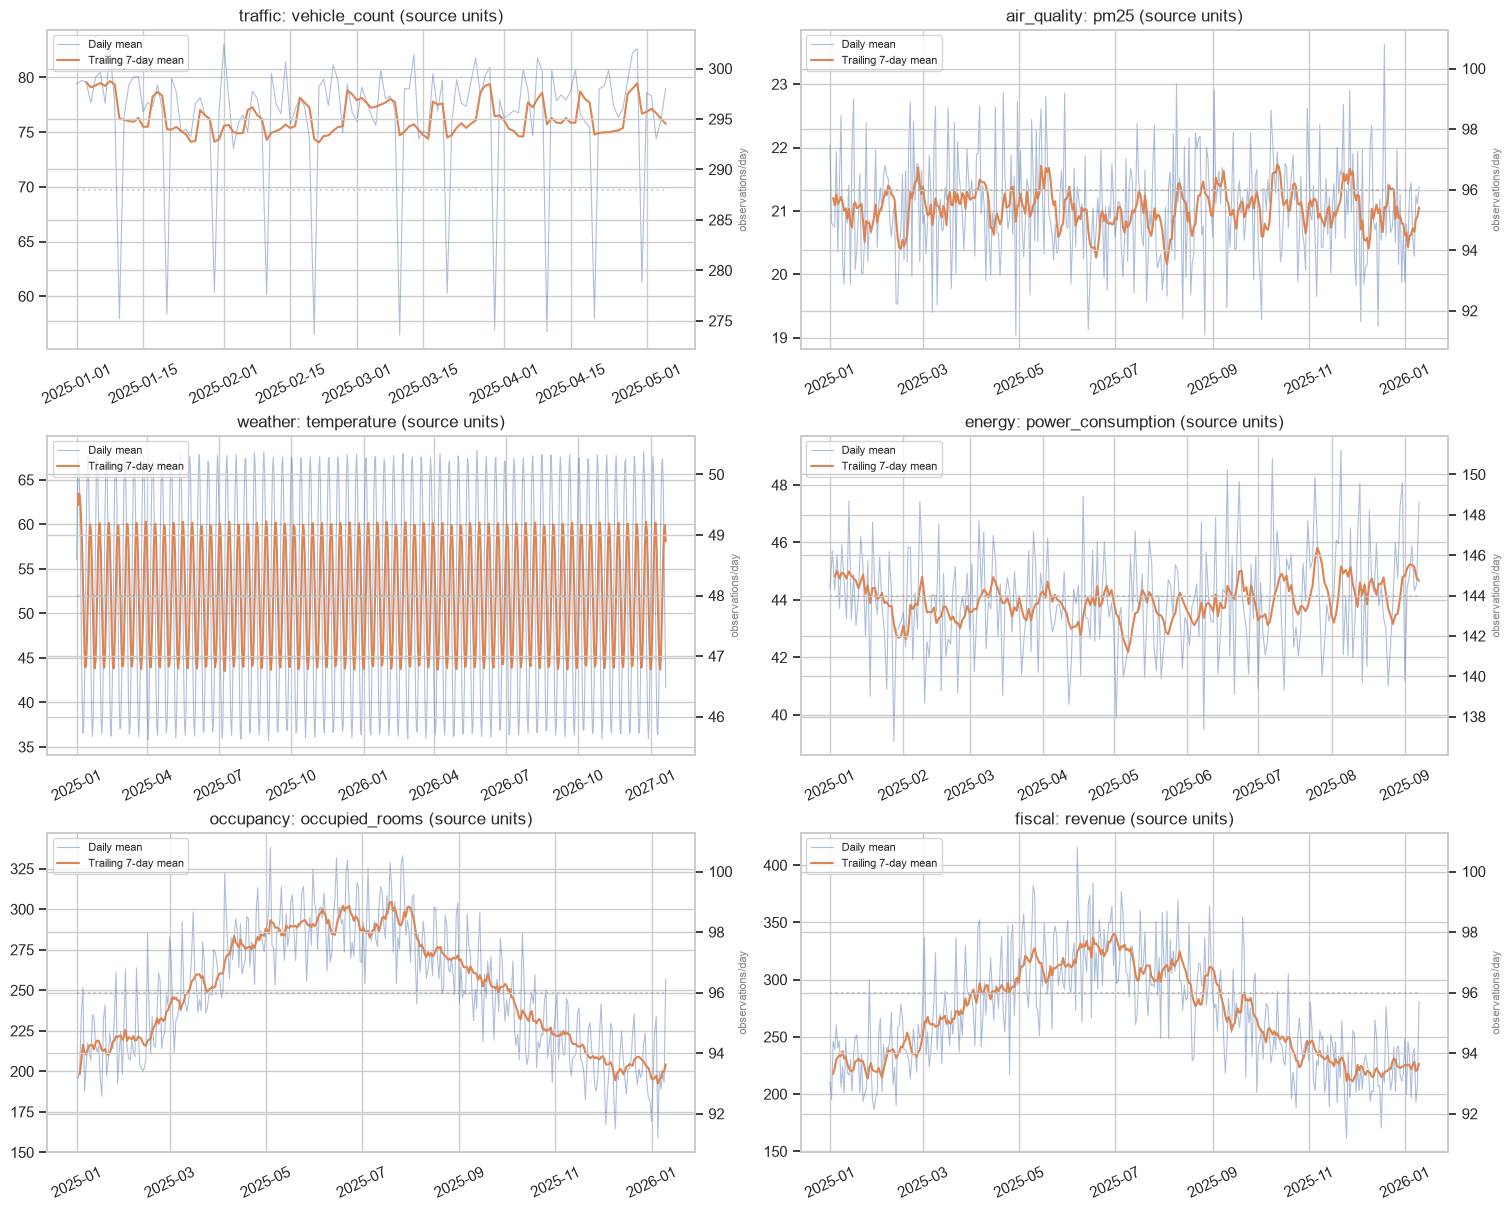

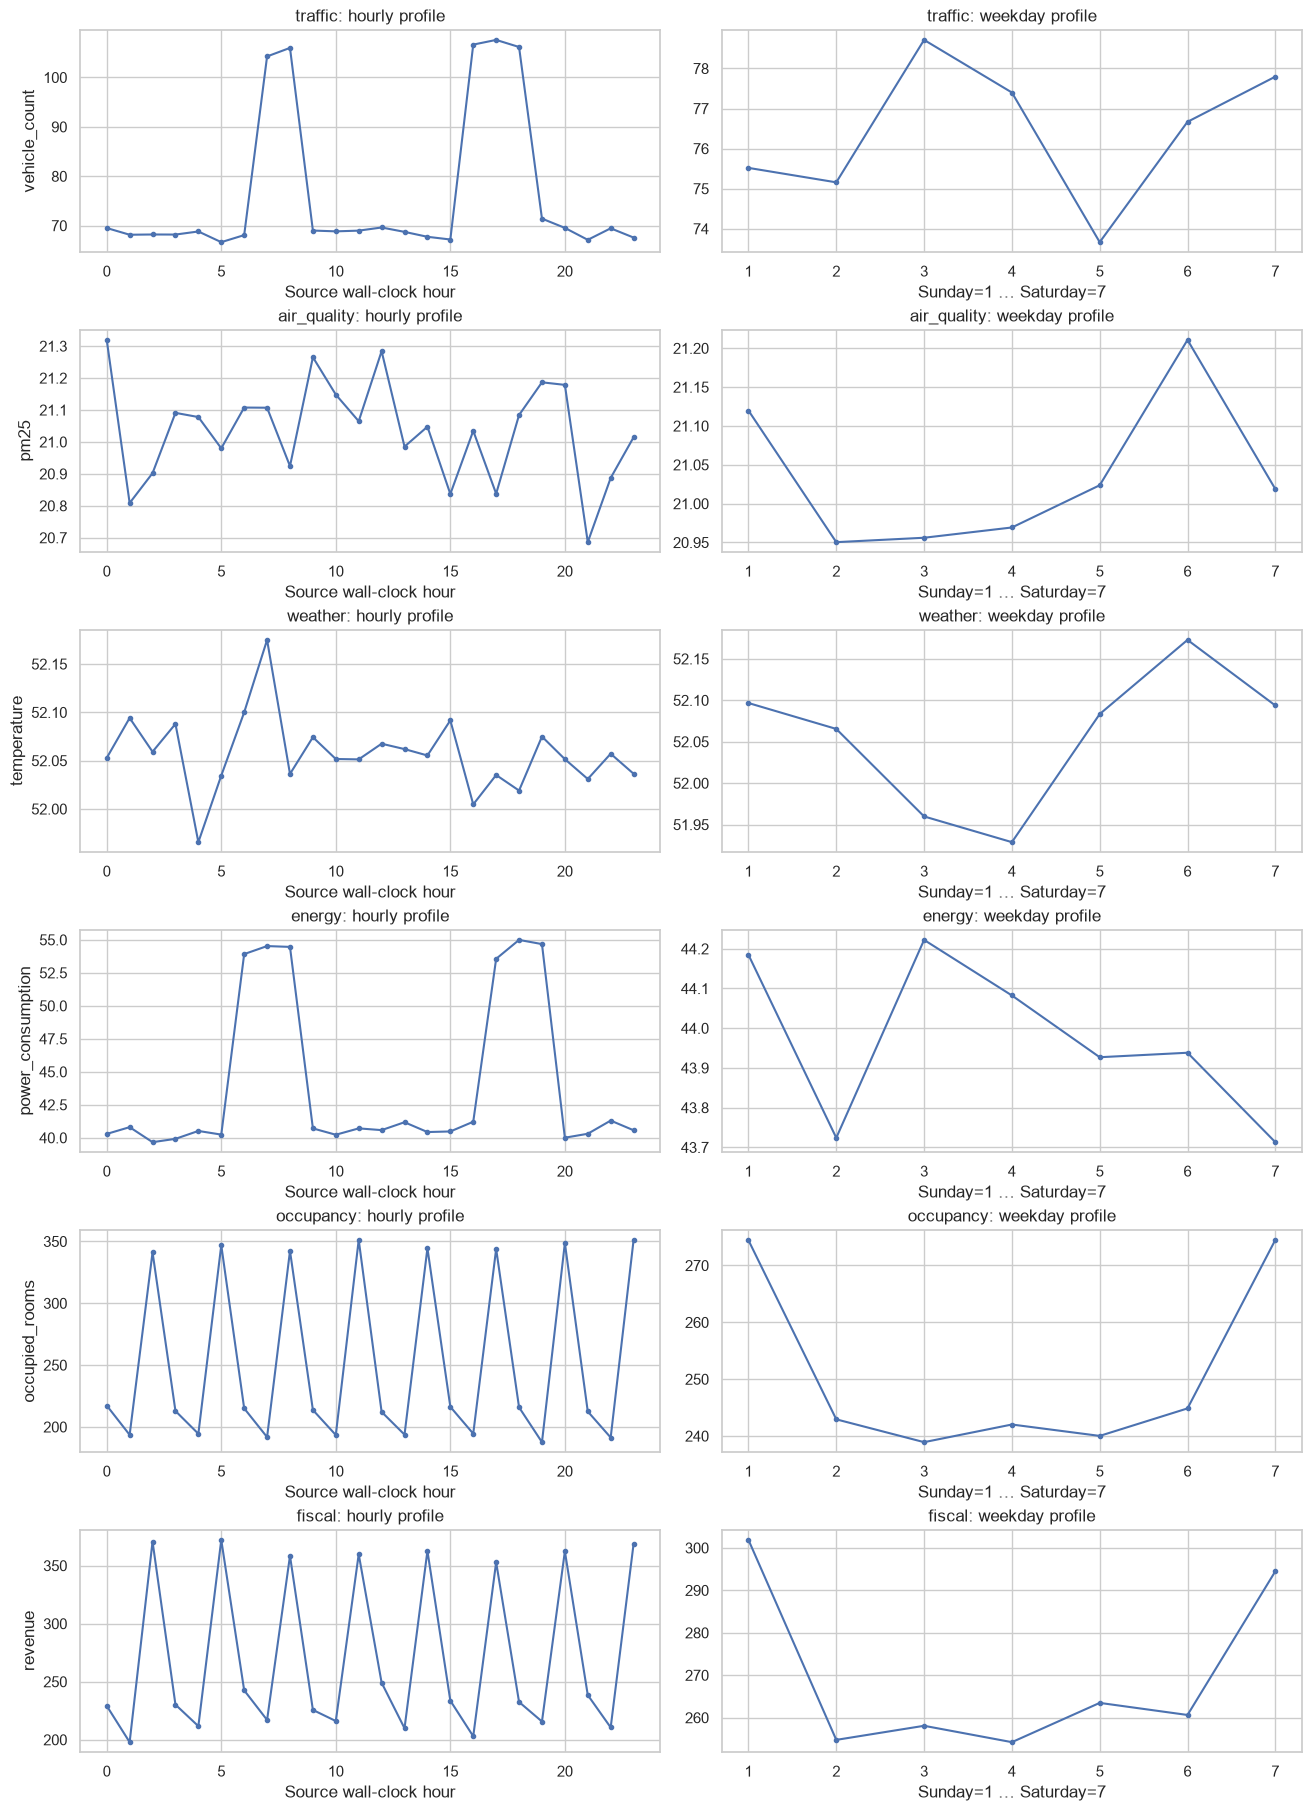

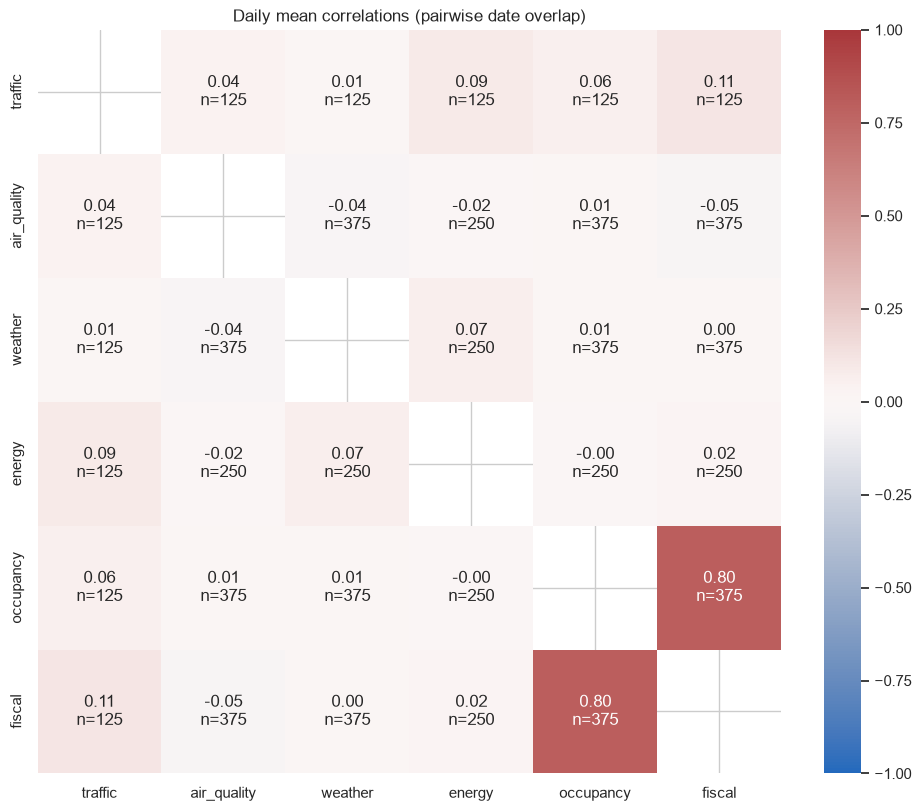

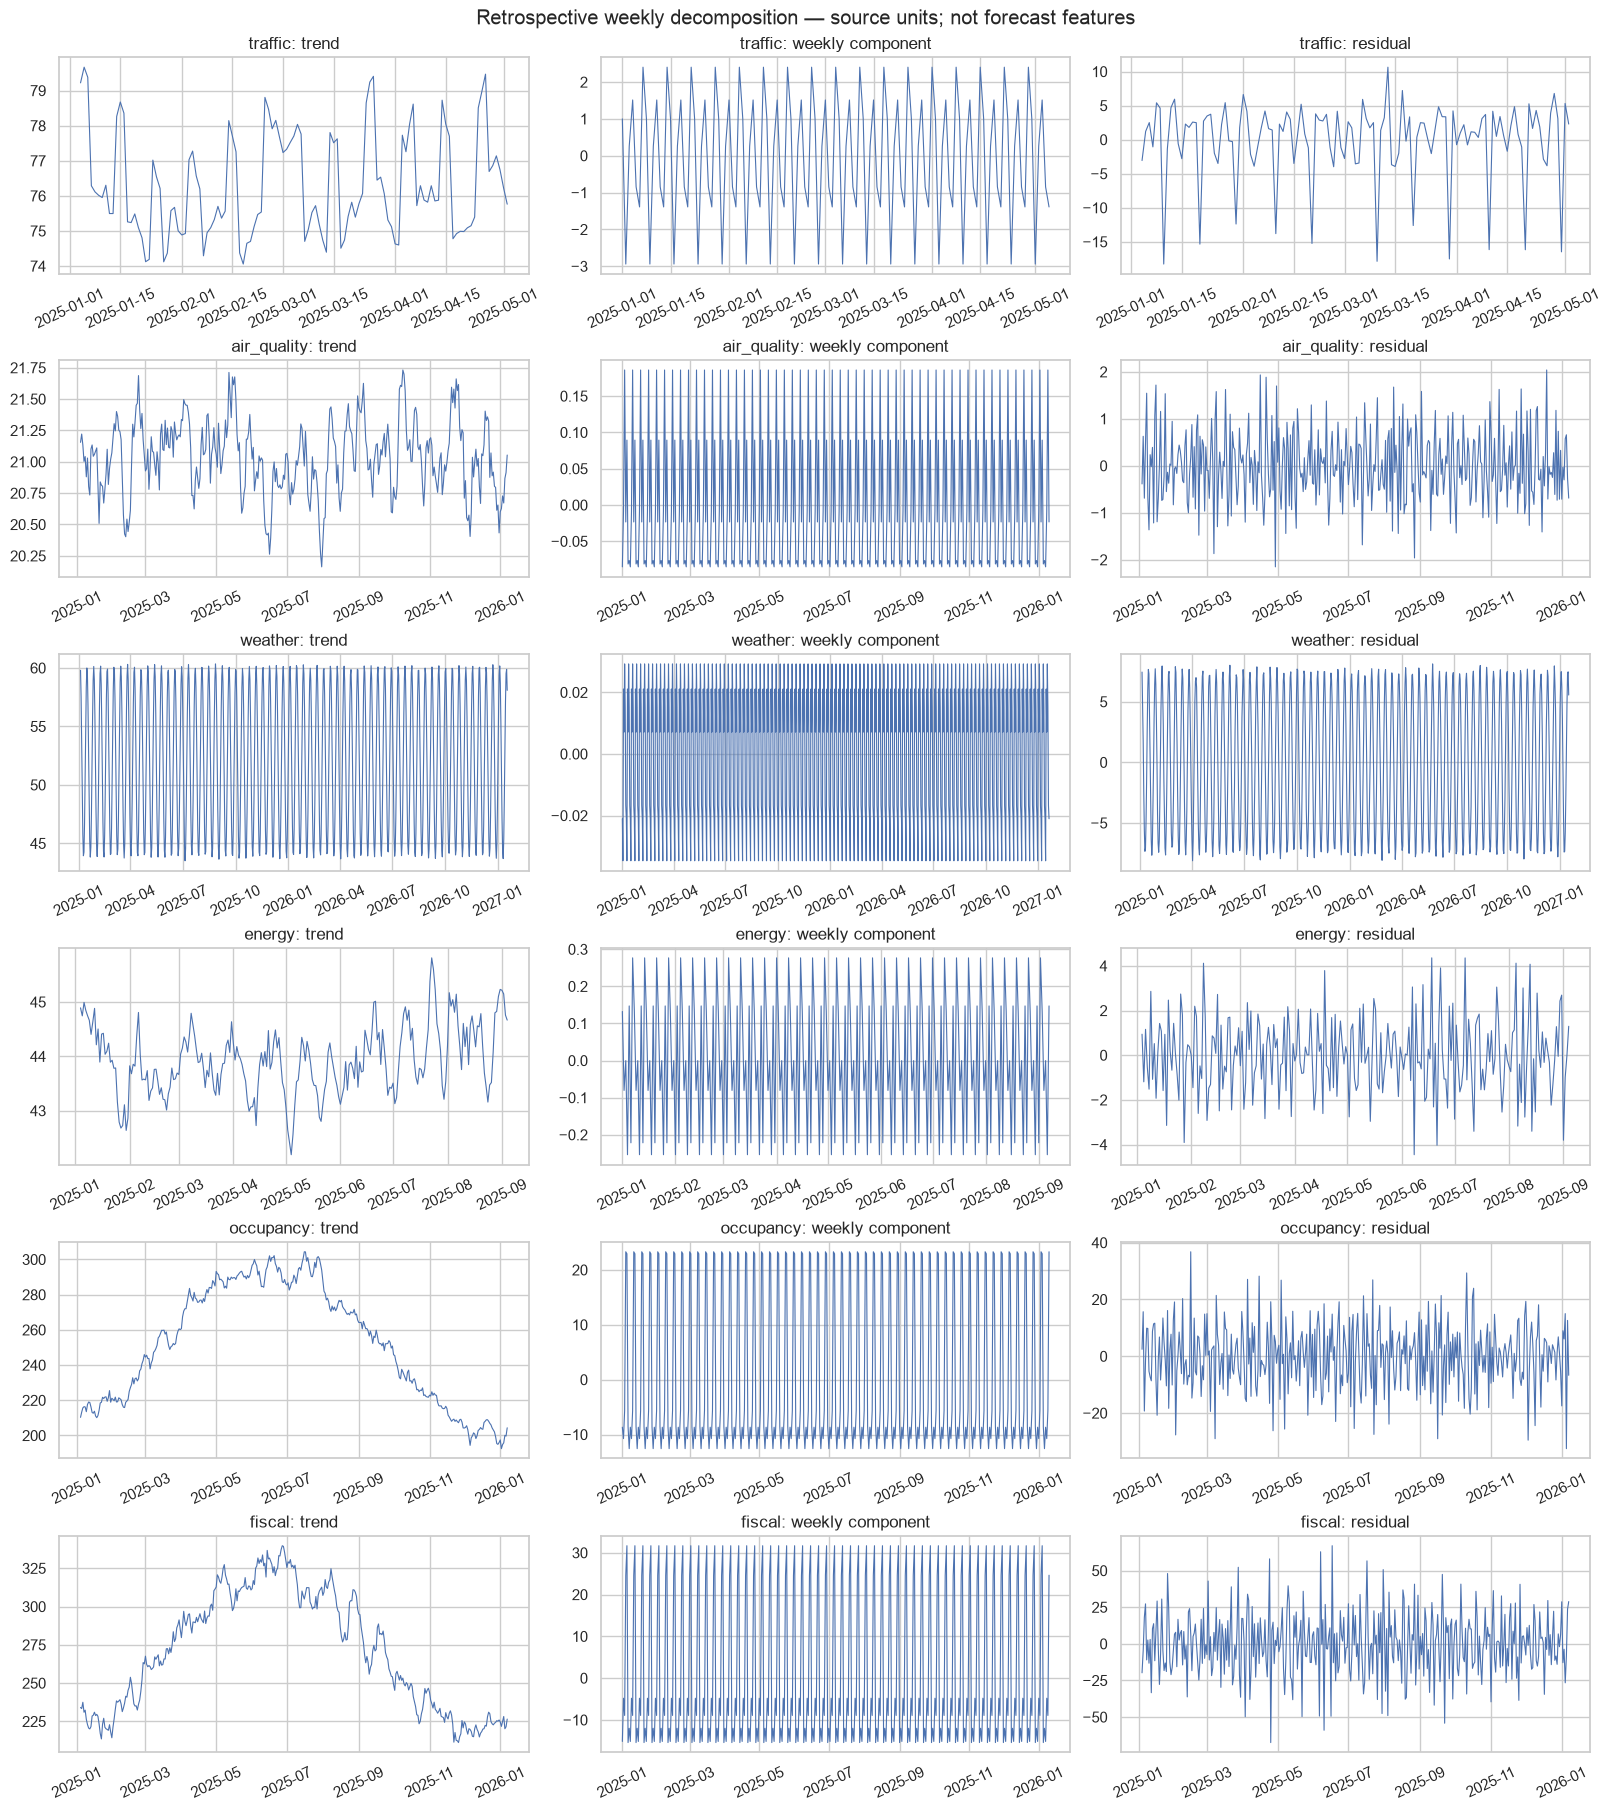

Dashboard: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day3/20260914T142210469836Z/dashboard.html


In [8]:
import base64

chart_paths = []
fig, axes = plt.subplots(3, 2, figsize=(15, 12), constrained_layout=True)
for ax, (kind, data) in zip(axes.flat, daily.items()):
    ax.plot(data.index, data["mean"], alpha=.45, linewidth=.8, label="Daily mean")
    ax.plot(data.index, data["mean"].rolling("7D", min_periods=3).mean(), label="Trailing 7-day mean")
    ax.set_title(f"{kind}: {SERIES[kind]} (source units)")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(fontsize=8, loc="upper left")
    count_axis = ax.twinx()
    count_axis.plot(data.index, data["n"], color="gray", linestyle=":", alpha=.35)
    count_axis.set_ylabel("observations/day", color="gray", fontsize=8)
path = OUTPUT / "daily_dashboard.png"
fig.savefig(path, dpi=130)
chart_paths.append(path)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(6, 2, figsize=(13, 18), constrained_layout=True)
for row, kind in enumerate(SERIES):
    axes[row, 0].plot(hourly[kind]["hour"], hourly[kind]["mean"], marker=".")
    axes[row, 0].set(title=f"{kind}: hourly profile", xlabel="Source wall-clock hour", ylabel=SERIES[kind])
    axes[row, 1].plot(weekday[kind]["weekday_sun1"], weekday[kind]["mean"], marker=".")
    axes[row, 1].set(title=f"{kind}: weekday profile", xlabel="Sunday=1 … Saturday=7")
path = OUTPUT / "calendar_profiles.png"
fig.savefig(path, dpi=130)
chart_paths.append(path)
plt.show()
plt.close(fig)

matrix = pd.DataFrame(np.nan, index=SERIES, columns=SERIES)
labels = pd.DataFrame("", index=SERIES, columns=SERIES)
for _, r in correlations.iterrows():
    for a, b in [(r["left"], r["right"]), (r["right"], r["left"])]:
        matrix.loc[a, b] = r["pearson_daily_means"]
        labels.loc[a, b] = f"{r['pearson_daily_means']:.2f}\nn={r['overlap_days']}"
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
sns.heatmap(matrix, mask=matrix.isna(), annot=labels, fmt="", cmap="vlag",
            vmin=-1, vmax=1, center=0, square=True, ax=ax)
ax.set_title("Daily mean correlations (pairwise date overlap)")
path = OUTPUT / "correlation_heatmap.png"
fig.savefig(path, dpi=130)
chart_paths.append(path)
plt.show()
plt.close(fig)

if decompositions:
    fig, axes = plt.subplots(len(decompositions), 3, figsize=(16, 3 * len(decompositions)), squeeze=False, constrained_layout=True)
    for row, (kind, data) in enumerate(decompositions.items()):
        for col, component in enumerate(("trend", "weekly_component", "residual")):
            axes[row, col].plot(data.index, data[component], linewidth=.8)
            axes[row, col].set_title(f"{kind}: {component.replace('_', ' ')}")
            axes[row, col].tick_params(axis="x", rotation=25)
    fig.suptitle("Retrospective weekly decomposition — source units; not forecast features")
    path = OUTPUT / "weekly_decomposition.png"
    fig.savefig(path, dpi=110)
    chart_paths.append(path)
    plt.show()
    plt.close(fig)

html = ['<!doctype html><html><head><meta charset="utf-8"><title>SparkCity Day 3</title>',
        '<style>body{font:16px system-ui;max-width:1200px;margin:40px auto;padding:0 20px}'
        'img{width:100%}table{border-collapse:collapse;font-size:13px}'
        'td,th{padding:8px;border:1px solid #ddd}section{overflow-x:auto}</style></head><body>',
        '<h1>SparkCity — Day 3 analysis</h1>',
        f'<p>Day 2 snapshot: {DAY2.name} · Day 3 run: {RUN_ID}</p>',
        '<p>Exploratory analysis of synthetic data. Units/timezone unconfirmed. '
        'Correlations are temporal associations, not causal or matched-location evidence.</p>',
        '<h2>Coverage</h2><section>', coverage_df.to_html(index=False), '</section>']
for path in chart_paths:
    encoded = base64.b64encode(path.read_bytes()).decode()
    html.append(f'<img alt="{path.stem}" src="data:image/png;base64,{encoded}">')
html += ['<h2>Correlation study</h2><section>', correlations.to_html(index=False), '</section>',
         '<h2>Trends (source units/day)</h2><section>', trend_df.to_html(index=False), '</section>',
         '<p>Null rolling features mean no observations in that elapsed window; they are not zero measurements.</p>',
         '<h2>Instructor-aligned analyses</h2><p>Decomposition is retrospective. Pattern flags use prior '
         'same-weekday history only; missing flags mean unassessed, not normal. Spatial results require stable '
         'locations and simultaneous observations. None of these descriptive checks establish causality.</p>',
         '<h3>Pattern-deviation review</h3><section>', pd.DataFrame(pattern_summary).to_html(index=False), '</section>',
         '<h3>Spatial evidence audit</h3><section>', pd.DataFrame(spatial_status).to_html(index=False), '</section>',
         '<h3>Hourly correlations: ten largest absolute coefficients</h3><p>Exploratory selection, not significance. '
         'Full pair coverage and observation counts are exported in instructor_extensions.</p><section>',
         hourly_correlations.dropna(subset=["pearson"]).sort_values("pearson", key=lambda s: s.abs(), ascending=False).head(10).to_html(index=False),
         '</section>']
for kind, profiles in calendar_profiles.items():
    html += [f'<details><summary>{kind}: monthly and weekend profiles</summary><section>',
             profiles["year_month"].to_html(index=False), profiles["is_weekend"].to_html(index=False),
             '</section></details>']
html += ['<p>Feature availability: feature_availability.csv. Per-sensor trends and analysis evidence: '
         'instructor_extensions/. Completion checklist: completion_checklist.json.</p>', '</body></html>']
(OUTPUT / "dashboard.html").write_text("\n".join(html))
print("Dashboard:", OUTPUT / "dashboard.html")

## 7. Finish and hand off to Day 4
A complete manifest is written after feature checks and report exports. Six feature tables preserve all accepted temporal rows; city zones are copied as reference. Source measurement columns and Day 2 quality flags remain available for sensitivity analysis.

For modeling: define the prediction horizon, use chronological train/test periods, distinguish prior-only predictors from current-reading features, and handle sparse-history nulls explicitly. Consider grouped analyses and stationarity diagnostics before interpreting aggregate correlations.

In [9]:
assert hashlib.sha256((DAY2 / "manifest.json").read_bytes()).hexdigest() == source_manifest_hash
assert input_hashes == {kind: dataset_hash(DAY2 / kind) for kind in input_hashes}, "Day 2 inputs changed during this run."
checklist = {
    "temporal_profiles": len(calendar_profiles) == 6,
    "decomposition_assessed": len(decomposition_status) == 6,
    "pattern_deviations_assessed": len(pattern_summary) == 6,
    "daily_and_hourly_correlations": len(correlations) == 15 and len(hourly_correlations) > 0,
    "spatial_evidence_audited": len(spatial_status) == 6,
    "six_feature_tables_verified": len(feature_audit) == 6,
    "feature_availability_reported": len(availability_rows) > 0,
    "sensor_trends_exported": len(sensor_trend_counts) == 6,
    "dashboard_exported": (OUTPUT / "dashboard.html").is_file(),
}
assert all(checklist.values()), checklist
(OUTPUT / "completion_checklist.json").write_text(json.dumps(checklist, indent=2))
manifest = {
    "status": "complete", "run_id": RUN_ID, "day2_run": DAY2.name,
    "day2_manifest_sha256": source_manifest_hash,
    "day1_run": source_manifest["day1_run"],
    "input_sha256": input_hashes,
    "outlier_policy": source_manifest["outlier_policy"],
    "instructor_alignment": "docs/day3_instructor_alignment.md",
    "completion_checklist": checklist,
    "spatial_status": spatial_status,
    "decomposition_status": decomposition_status,
    "traffic_zone_aggregate": "aggregates/traffic_zone_daily",
    "spark": spark.version, "python": sys.version,
    "source_units": source_manifest.get("source_units"),
    "timestamp_semantics": source_manifest.get("timestamp_semantics"),
    "features": feature_audit, "reference_rows": expected["city_zones"],
    "lag_semantics": "previous observations within sensor",
    "rolling_semantics": "prior elapsed 7/30 days, excludes current timestamp",
    "current_reading_features": ["change_per_hour", "difference1_observation", "pct_change1_observation", "position_vs_prior", "occupancy_fraction", "net_revenue", "pm25_pm10_ratio", "vehicle_count_times_speed", "temperature_times_humidity", "voltage_times_current"],
    "correlation_semantics": "pairwise aligned daily observation means; minimum 14 dates",
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
for frame in frames.values():
    frame.unpersist()
print("Completed:", OUTPUT)
print("Open dashboard.html; read correlation_findings.md and trend_report.md.")
# spark.stop() when you have finished using this kernel.


Completed: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day3/20260914T142210469836Z
Open dashboard.html; read correlation_findings.md and trend_report.md.
